# TRISO starter model: FLiBe-cooled pebble (gFHR / KP-FHR-like) unit cell

Explicit, randomly packed TRISO particles (`openmc.model.pack_spheres` + `openmc.model.TRISO` +
`openmc.model.create_triso_lattice`) inside a 4 cm fuel pebble, with the pebbles arranged in a
body-centred-cubic (BCC) cell at 60 % pebble packing fraction, FLiBe coolant between pebbles, and
reflective boundaries on all six faces, so the result is **k-inf** of an infinite fresh pebble bed.

**Geometry and material source.** Pebble and TRISO dimensions and densities come from the public
**generic FHR (gFHR) benchmark**, as published by the INL/NRIC Virtual Test Bed,
[gFHR reactor description](https://mooseframework.inl.gov/virtual_test_bed/pbfhr/g_fhr/reactor_description.html)
(Tables 2–3; based on AGR-2 UCO TRISO). The TRISO radii are identical to the OECD/NEA MHTGR-350 benchmark
(NEA/NSC/R(2017)4, Table I.4; the kernel is 0.02125 cm there vs 0.0212 cm in gFHR).

| Item | Value used | Source |
|---|---|---|
| Kernel | UC0.5O1.5, r = 0.02125 cm (425 µm dia.), 10.5 g/cc | gFHR T3 / MHTGR-350 |
| Buffer | r_out = 0.03125 cm, 1.05 g/cc | gFHR T3 |
| IPyC | r_out = 0.03525 cm, 1.90 g/cc | gFHR T3 |
| SiC | r_out = 0.03875 cm, 3.18 g/cc | gFHR T3 |
| OPyC | r_out = 0.04275 cm, 1.90 g/cc | gFHR T3 |
| Pebble | core r = 1.38 cm (1.41 g/cc), fuel zone to 1.80 cm (matrix 1.74 g/cc), shell to 2.00 cm (1.74 g/cc) | gFHR T2 |
| TRISO per pebble | 11,660 (≈28.4 % of the fuel zone) baseline; 40 % variant | gFHR T2 |
| Pebble packing | 0.60 (random bed) → here, a regular BCC cell | gFHR T1 |
| Enrichment | **19.75 wt% U-235** (HALEU; the gFHR spec uses 19.55 %) | user choice |
| Coolant | FLiBe 2LiF-BeF2, Li-7 = 99.995 %, ρ = 2.413 − 4.884e-4·T[K] g/cc (~1.97 at 900 K) | gFHR spec / Janz correlation |

All materials are at 900 K. Graphite S(α,β) is applied to all carbon materials, but not to FLiBe
(ENDF/B-VIII.0 has no FLiBe thermal-scattering data).


In [1]:
import os, time
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import openmc
import openmc.model

print('OpenMC', openmc.__version__)
# ENDF/B-VIII.0 HDF5 library (set OPENMC_CROSS_SECTIONS to override)
openmc.config['cross_sections'] = os.environ.get(
    'OPENMC_CROSS_SECTIONS', '/workspace/nucdata/endfb-viii.0-hdf5/cross_sections.xml')
print('cross sections:', openmc.config['cross_sections'])
WORK = os.path.abspath('run'); os.makedirs(WORK, exist_ok=True)
FIG = os.path.abspath('figures'); os.makedirs(FIG, exist_ok=True)
T = 900.0            # K, all materials
ENRICH = 19.75       # wt% U-235
SEED = 20260929

OpenMC 0.16.0
cross sections: /workspace/nucdata/endfb-viii.0-hdf5/cross_sections.xml


## Materials

In [2]:
def graphite(name, rho):
    m = openmc.Material(name=name, temperature=T)
    m.add_element('C', 1.0)
    m.set_density('g/cm3', rho)
    m.add_s_alpha_beta('c_Graphite')
    return m

# UCO kernel: UC0.5 O1.5 (gFHR Table 3). Enrichment is given as a weight percent.
kernel = openmc.Material(name='UCO kernel', temperature=T)
w5 = ENRICH/100                       # U-235 weight fraction (U-234/236 neglected)
a5 = (w5/235.0439)/((w5/235.0439) + ((1-w5)/238.0508))
kernel.add_nuclide('U235', a5)
kernel.add_nuclide('U238', 1.0 - a5)
kernel.add_element('C', 0.5)
kernel.add_element('O', 1.5)
kernel.set_density('g/cm3', 10.5)

buffer_ = graphite('buffer', 1.05)
ipyc    = graphite('IPyC', 1.90)
opyc    = graphite('OPyC', 1.90)
sic = openmc.Material(name='SiC', temperature=T)
sic.add_element('Si', 1.0); sic.add_element('C', 1.0)
sic.set_density('g/cm3', 3.18)

matrix      = graphite('fuel-zone matrix', 1.74)
peb_core    = graphite('pebble core (low density)', 1.41)
peb_shell   = graphite('pebble shell', 1.74)

flibe = openmc.Material(name='FLiBe', temperature=T)
flibe.add_nuclide('Li7', 2.0*0.99995); flibe.add_nuclide('Li6', 2.0*0.00005)
flibe.add_element('Be', 1.0); flibe.add_element('F', 4.0)
flibe.set_density('g/cm3', 2.413 - 4.884e-4*T)
print('FLiBe density at %.0f K = %.4f g/cc' % (T, flibe.density))

FLiBe density at 900 K = 1.9734 g/cc


## TRISO particle, pebble and BCC unit cell
One TRISO universe is shared by every particle. `pack_spheres` places the particle centres in the
fuel-zone spherical shell (random sequential packing, and close random packing above ~38 %), then
`create_triso_lattice` puts them in a rectangular lattice so tracking stays fast.

In [3]:
R_KER, R_BUF, R_IPYC, R_SIC, R_OPYC = 0.02125, 0.03125, 0.03525, 0.03875, 0.04275  # cm
R_CORE, R_FUEL, R_PEB = 1.38, 1.80, 2.00                                          # cm
PEB_PF = 0.60
V_TRISO = 4/3*pi*R_OPYC**3
V_FUELZONE = 4/3*pi*(R_FUEL**3 - R_CORE**3)
N_SPEC = 11660   # gFHR Table 2

def build_model(n_triso=None, pf=None, particles=10000, batches=70, inactive=20):
    s = [openmc.Sphere(r=r) for r in (R_KER, R_BUF, R_IPYC, R_SIC)]
    triso_cells = [openmc.Cell(fill=kernel, region=-s[0]),
                   openmc.Cell(fill=buffer_, region=+s[0] & -s[1]),
                   openmc.Cell(fill=ipyc,    region=+s[1] & -s[2]),
                   openmc.Cell(fill=sic,     region=+s[2] & -s[3]),
                   openmc.Cell(fill=opyc,    region=+s[3])]
    triso_univ = openmc.Universe(cells=triso_cells, name='TRISO')

    s_core, s_fuel, s_peb = (openmc.Sphere(r=r) for r in (R_CORE, R_FUEL, R_PEB))
    fuel_zone = +s_core & -s_fuel
    t0 = time.time()
    centers = openmc.model.pack_spheres(R_OPYC, region=fuel_zone, pf=pf, num_spheres=n_triso, seed=SEED)
    t_pack = time.time() - t0
    trisos = [openmc.model.TRISO(R_OPYC, triso_univ, c) for c in centers]
    ll, ur = (-R_FUEL,)*3, (R_FUEL,)*3
    shape = (12, 12, 12)
    pitch = [(b - a)/n for a, b, n in zip(ll, ur, shape)]
    lattice = openmc.model.create_triso_lattice(trisos, ll, pitch, shape, matrix)

    pebble_univ = openmc.Universe(name='pebble', cells=[
        openmc.Cell(fill=peb_core, region=-s_core, name='pebble core'),
        openmc.Cell(fill=lattice, region=fuel_zone, name='fuel zone (TRISO lattice)'),
        openmc.Cell(fill=peb_shell, region=+s_fuel & -s_peb, name='pebble shell'),
        openmc.Cell(fill=peb_shell, region=+s_peb, name='outside (never reached)')])

    # BCC cell: one pebble at the centre + 8 corner eighths = 2 pebbles per cube
    L = (2*4/3*pi*R_PEB**3/PEB_PF)**(1/3)
    h = L/2
    assert L*np.sqrt(3)/2 >= 2*R_PEB, 'pebbles overlap'
    box = openmc.model.RectangularParallelepiped(-h, h, -h, h, -h, h, boundary_type='reflective')
    positions = [(0, 0, 0)] + [(sx*h, sy*h, sz*h) for sx in (-1, 1) for sy in (-1, 1) for sz in (-1, 1)]
    root_cells, outside_pebbles = [], -box
    for p in positions:
        sp = openmc.Sphere(x0=p[0], y0=p[1], z0=p[2], r=R_PEB)
        c = openmc.Cell(fill=pebble_univ, region=-sp & -box, name=f'pebble @ {p}')
        c.translation = p
        root_cells.append(c)
        outside_pebbles &= +sp
    root_cells.append(openmc.Cell(fill=flibe, region=outside_pebbles, name='FLiBe'))
    geom = openmc.Geometry(root_cells)

    settings = openmc.Settings()
    settings.particles, settings.batches, settings.inactive = particles, batches, inactive
    settings.temperature = {'method': 'interpolation', 'default': T}
    settings.source = openmc.IndependentSource(
        space=openmc.stats.Box((-h, -h, -h), (h, h, h)),
        constraints={'fissionable': True})
    settings.source_rejection_fraction = 1e-3   # kernels are only ~0.8 % of the cell volume
    settings.seed = SEED
    settings.output = {'tallies': False}
    model = openmc.Model(geometry=geom, settings=settings)
    info = dict(n_triso=len(centers), pf_fuelzone=len(centers)*V_TRISO/V_FUELZONE,
                t_pack=t_pack, L=L, peb_pf=2*4/3*pi*R_PEB**3/L**3)
    return model, info, (L, R_FUEL)

model, info, (L, _) = build_model(n_triso=N_SPEC)
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in info.items()})

{'n_triso': 11660, 'pf_fuelzone': 0.2843, 't_pack': 4.3372, 'L': 4.816, 'peb_pf': 0.6}


## Geometry plot (xy slice through the pebble centres at z = 0, coloured by material)

/home/box/micromamba/envs/openmc/lib/python3.12/site-packages/openmc/plots.py:1389: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Preparing distributed cell instances...



 =======================>     PLOTTING SUMMARY     <========================

Plot ID: 1
Plot file: cell.png
Universe depth: -1
Plot Type: Slice
Origin: 0 0 0
Width: 4.81599226276091 4.81599226276091
Coloring: Materials
Basis: XY
Pixels: 2000 2000

Plot ID: 2
Plot file: zoom.png
Universe depth: -1
Plot Type: Slice
Origin: 1.55 0 0
Width:  0.8  0.8
Coloring: Materials
Basis: XY
Pixels: 1600 1600

 Processing plot 1: cell.png...


 Processing plot 2: zoom.png...


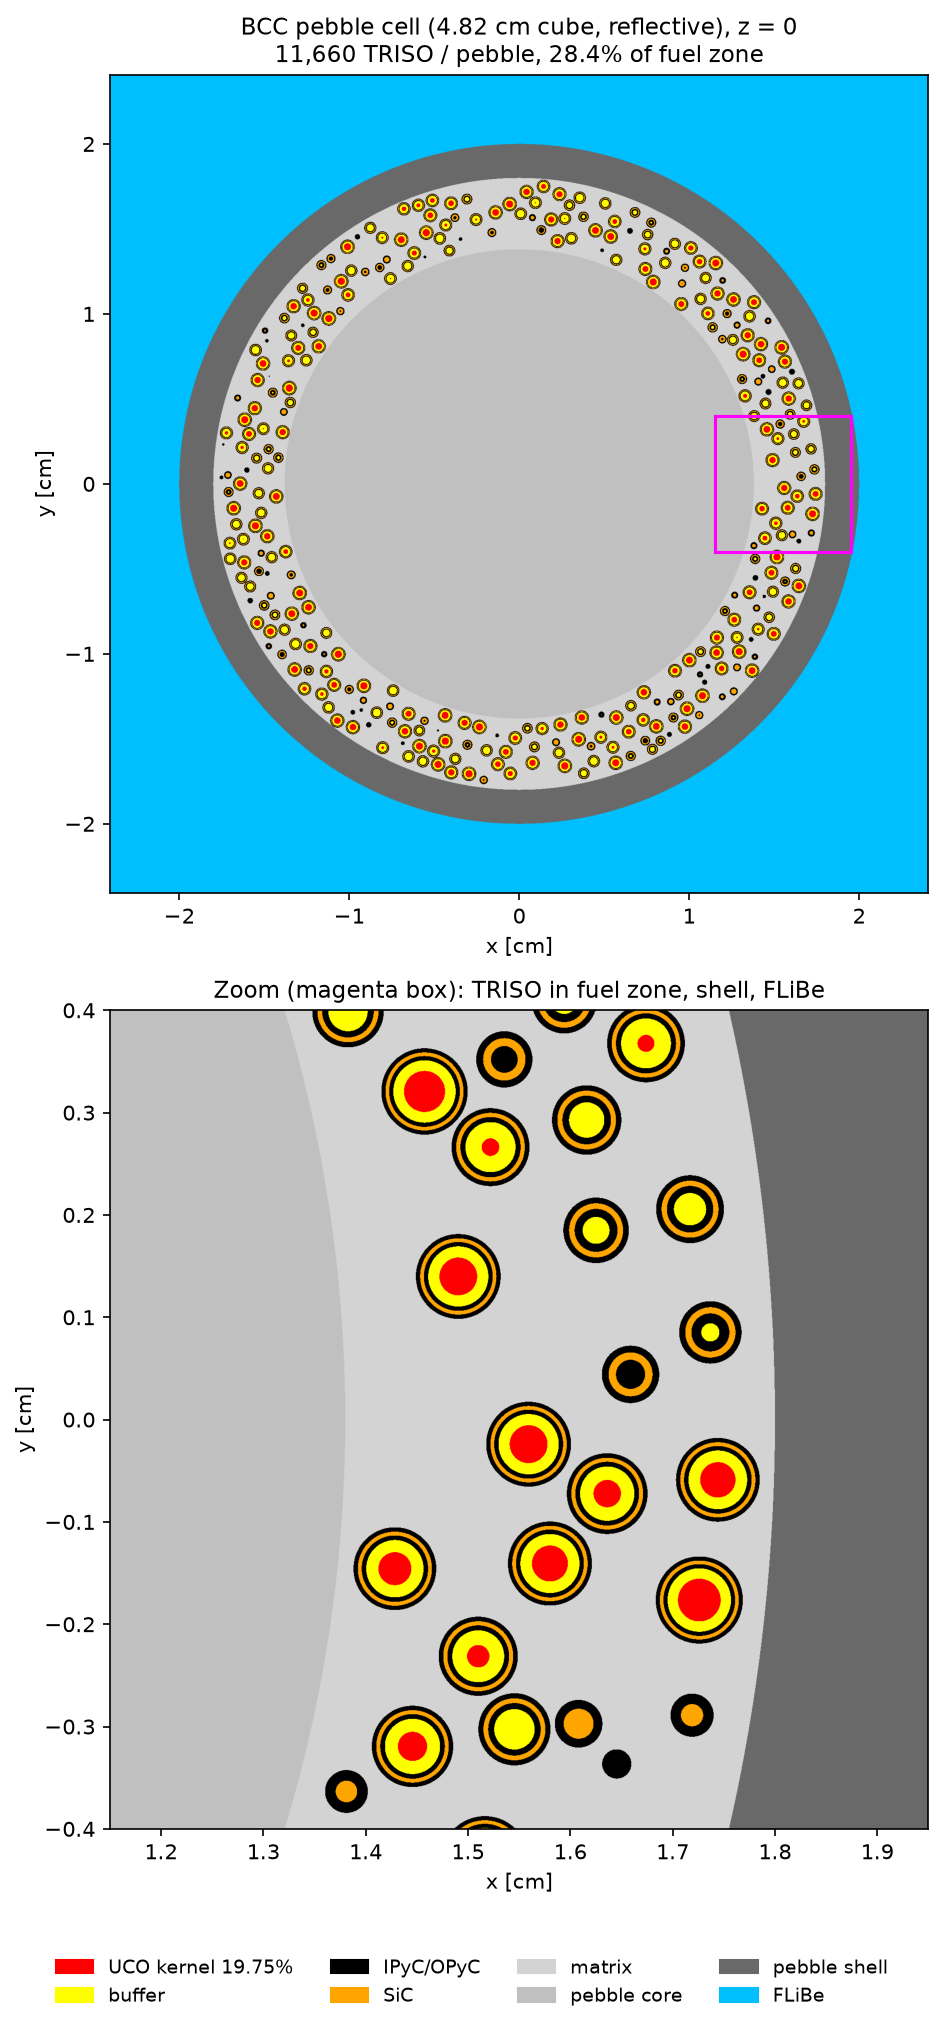

In [4]:
colors = {kernel: 'red', buffer_: 'yellow', ipyc: 'black', sic: 'orange', opyc: 'black',
          matrix: 'lightgray', peb_core: 'silver', peb_shell: 'dimgray', flibe: 'deepskyblue'}
def raster(width, origin, px, name):
    p = openmc.Plot(); p.filename = name; p.basis = 'xy'; p.origin = origin
    p.width = (width, width); p.pixels = (px, px); p.color_by = 'material'; p.colors = colors
    return p
plots = openmc.Plots([raster(L, (0, 0, 0), 2000, 'cell'),
                      raster(0.8, (1.55, 0.0, 0.0), 1600, 'zoom')])
model.plots = plots
model.plot_geometry(cwd=WORK)

from matplotlib.patches import Patch
imgs = [plt.imread(os.path.join(WORK, f)) for f in ('cell.png', 'zoom.png')]
fig, ax = plt.subplots(2, 1, figsize=(7, 13.5), dpi=150)
ax[0].imshow(imgs[0], extent=[-L/2, L/2, -L/2, L/2])
ax[0].set_title(f'BCC pebble cell ({L:.2f} cm cube, reflective), z = 0\n'
                f'{info["n_triso"]:,} TRISO / pebble, {100*info["pf_fuelzone"]:.1f}% of fuel zone', fontsize=11)
ax[0].add_patch(plt.Rectangle((1.15, -0.4), 0.8, 0.8, fill=False, ec='magenta', lw=1.5))
ax[1].imshow(imgs[1], extent=[1.15, 1.95, -0.4, 0.4])
ax[1].set_title('Zoom (magenta box): TRISO in fuel zone, shell, FLiBe', fontsize=11)
for a in ax: a.set_xlabel('x [cm]'); a.set_ylabel('y [cm]')
fig.legend(handles=[Patch(color=c, label=l) for c, l in [
    ('red', 'UCO kernel 19.75%'), ('yellow', 'buffer'), ('black', 'IPyC/OPyC'), ('orange', 'SiC'),
    ('lightgray', 'matrix'), ('silver', 'pebble core'), ('dimgray', 'pebble shell'), ('deepskyblue', 'FLiBe')]],
    loc='lower center', ncol=4, fontsize=9, frameon=False)
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(os.path.join(FIG, 'triso_pebble_geometry.png'), dpi=150)
plt.show()

## Eigenvalue run: baseline gFHR particle loading (11,660 TRISO per pebble)

In [5]:
def run(model, tag):
    d = os.path.join(WORK, tag); os.makedirs(d, exist_ok=True)
    t0 = time.time()
    sp = model.run(cwd=d, threads=os.cpu_count(), output=False)
    wall = time.time() - t0
    with openmc.StatePoint(sp) as s:
        k = s.keff
        tr = s.runtime
    print(f'{tag}: k-inf = {k.n:.5f} ± {k.s:.5f}  (wall {wall:.0f} s, transport {tr["transport"]:.0f} s)')
    return k, wall

k_base, wall_base = run(model, 'baseline_11660')

baseline_11660: k-inf = 1.38258 ± 0.00149  (wall 271 s, transport 259 s)


## Variant: 40 % TRISO packing in the fuel zone (upper end of the typical 30–40 % range)

In [6]:
model40, info40, _ = build_model(pf=0.40)
print(f"{info40['n_triso']:,} TRISO, pf = {info40['pf_fuelzone']:.3f}, packing took {info40['t_pack']:.1f} s")
k_40, wall_40 = run(model40, 'pf40')

16,403 TRISO, pf = 0.400, packing took 42.9 s


pf40: k-inf = 1.30663 ± 0.00114  (wall 352 s, transport 336 s)


In [7]:
hm_per_triso = 4/3*pi*R_KER**3 * 10.5 * (238.0/(238.0+0.5*12.011+1.5*15.999))  # approx g U per particle
rows = [('gFHR spec', info, k_base, wall_base), ('pf 0.40', info40, k_40, wall_40)]
print(f"{'case':10s} {'TRISO/peb':>10s} {'pf':>6s} {'gU/peb':>7s} {'k-inf':>18s} {'wall s':>7s}")
for name, i, k, w in rows:
    print(f"{name:10s} {i['n_triso']:10,d} {i['pf_fuelzone']:6.3f} {i['n_triso']*hm_per_triso:7.2f} "
          f"{k.n:10.5f} ± {k.s:.5f} {w:7.0f}")

case        TRISO/peb     pf  gU/peb              k-inf  wall s
gFHR spec      11,660  0.284    4.37    1.38258 ± 0.00149     271
pf 0.40        16,403  0.400    6.15    1.30663 ± 0.00114     352


## Notes / caveats
* This is a **fresh-fuel, infinite-lattice, isothermal (900 K)** pebble-bed k-inf. It is not the gFHR
  equilibrium-core k-eff, and it has no leakage, burnup, fission products, control, or reflector.
* The BCC arrangement is regular. A real pebble bed is random, at about 60 % packing, and lower near
  walls. Comparing BCC with random pebble arrangements usually shifts k by a few hundred pcm at most;
  check this for your design.
* The TRISO positions are one random realisation (`SEED`). Change the seed to see the
  realisation-to-realisation spread.
* The gFHR spec lists 11,660 TRISO/pebble, while the ANL SAM paper (OSTI 2566105) quotes 9,022 for the
  same benchmark. The baseline here uses 11,660. The VTB core table's 3.4 g of initial heavy metal per pebble matches about 9,022 particles, so re-run with `build_model(n_triso=9022)` to check.
* For a prismatic or compact design (MHTGR-350-like), `pack_spheres` also supports cylinders and boxes.
  The same TRISO universe drops straight into a compact. See the Cardinal `gas_compact` tutorial and the
  VTB `htgr/assembly` model in the README.
